# Lab 1-2 - Środowisko Programistyczne + Wprowadzenie do uczenia maszynowego

## Konfiguracja środowiska programistycznego
### Google Colab: https://colab.research.google.com/github/yy/dviz-course/blob/master/docs/m01-intro/lab01.ipynb
### Pycharm: https://www.jetbrains.com/help/pycharm/creating-virtual-environment.html

## Przydatne linki

### Integracja Colab-GitHub: https://colab.research.google.com/github/googlecolab/colabtools/blob/master/notebooks/colab-github-demo.ipynb

### Synchronizacja Pycharm-Github: https://www.jetbrains.com/help/pycharm/github.html

### Podstawy operacji na ramkach danych w Pandas: https://www.kaggle.com/learn/pandas

### Tworzenie wykresów w seaborn: https://www.kaggle.com/code/vijayjoshi17/seaborn-guide-all-important-plots

# Zadania:



## Ocena zadań
### Zasady oceniania dla listy 1:
Student w ciągu 5-6 minut prezentuje i omawia napisany przez siebie kod, a następnie prowadzący zadaje 1-2 pytania do całości listy w celu werfikacji czy student rozumie kod, który zaprezentował.

Za każde zadanie można dostać maksymalnie 2 punkty.

### Ocena jest redukowana o 1 punkt w przypadku:
- niepełnej realizacji polecenia (np. brak jednego z podpunktów)
- niezdolności do odpowiedzi na pytanie ze zrozumienia kodu
- popełnienia błędu w kodzie

## Wykorzystywane zbiory danych
Poniższa lista zadań wykorzystuje dwa zbiory danych dostępne na platformie Kaggle:

### Dla zadań 1-4:

Student Lifestyle and Academic Performance Dataset: https://www.kaggle.com/datasets/sehaj1104/student-lifestyle-and-academic-performance-dataset

### Dla zadania nr 5:

Social Media Viral Content and Engagement Metrics: https://www.kaggle.com/datasets/aliiihussain/social-media-viral-content-and-engagement-metrics

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## Dokumentacje bibliotek potrzebnych do realizacji zadań:
- pandas: https://pandas.pydata.org/docs/index.html
- seaborn: https://seaborn.pydata.org/
- matplotlib: https://matplotlib.org/stable/


In [69]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Zadanie 1
Wyświetl ramkę danych spełniającą następujące kryteria:
- ramka zawiera wyłącznie informacje o wieku studentów oraz tym jak spędzają czas.
- ramka zawiera informacje wyłącznie o 15 studentach z najwyższą średnią (CGPA)
- ramka jest posortowana pod względem średniej, tak by student z najwyższą średnią był wyświetlany jako pierwszy

In [34]:
# wczytanie danych do zadania 1-4
df = pd.read_csv("/content/student_lifestyle_performance_dataset.csv")

In [35]:
df["Gym_Hours_per_Day"] = df["Gym_Hours_per_Week"] / 7

result = (
    df
    .nlargest(15, "CGPA")
    [["Age", "Study_Hours_per_Day", "Sleep_Hours", "Screen_Time_Hours", "Gym_Hours_per_Day"]]
)

result

,Age,Study_Hours_per_Day,Sleep_Hours,Screen_Time_Hours,Gym_Hours_per_Day
109,23,5.83,9.26,7.19,0.864286
405,17,6.87,7.92,2.21,2.590000
464,25,5.18,9.13,7.92,1.121429
657,22,6.85,8.45,3.84,1.810000
843,24,4.64,8.34,3.28,0.512857
171,20,8.05,7.34,6.46,0.000000
475,19,5.71,8.07,2.98,1.851429
639,19,7.30,8.57,3.96,1.177143
659,20,3.85,9.22,7.14,0.744286
682,25,4.87,8.25,4.95,0.000000


## Zadanie 2
dodaj do ramki danych kolumnę z wyliczoną średnią ilością czasu wolnego, którym student dysponuje w ciągu dnia.


### Wyliczając wartość czasu wolnego przyjmij następujące założenia:
- czas wolny studenta to cały czas, którego **NIE** poświęca na naukę, ćwiczenia, sen oraz siedzenie przed ekranem oraz na jedzenie i czynności higieniczne
- około godzina czasu spędzonego przed ekranem to czas poświęcony na naukę
- jedzenie i czynności higieniczne zajmują przeciętnej osobie 2,5 godziny w ciągu dnia

### Następnie wyświetl otrzymaną ramkę danych tak, by spełniała następujące kryteria:
- wyświetl wyłącznie dodatkową kolumnę oraz kolumny wykorzystane do wyliczenia ilości czasu wolnego
- kolumna z czasem wolnym powinna wyświetlać się jako pierwsza z lewej
- czas wolny powinien być zaokrąglony do drugiej liczby po przecinku

In [65]:
df["Free_Time"] = (
    24
    - df["Study_Hours_per_Day"]
    - df["Gym_Hours_per_Day"]
    - df["Sleep_Hours"]
    - (df["Screen_Time_Hours"] - 1)
    - 2.5
).round(2)

result = df[[
    "Free_Time",
    "Study_Hours_per_Day",
    "Gym_Hours_per_Day",
    "Sleep_Hours",
    "Screen_Time_Hours"
]]

result

,Free_Time,Study_Hours_per_Day,Gym_Hours_per_Day,Sleep_Hours,Screen_Time_Hours
0,1.91,4.14,0.381429,6.84,9.23
1,5.69,5.97,2.230000,5.52,3.09
2,10.54,3.19,0.360000,3.39,5.02
3,2.08,4.77,0.000000,6.44,9.21
4,4.36,5.42,1.418571,6.54,4.76
...,...,...,...,...,...
995,6.60,4.60,1.805714,5.26,4.23
996,7.64,4.02,0.408571,6.55,3.88
997,5.15,4.28,0.000000,8.43,4.64
998,3.74,6.42,1.440000,6.06,4.84


## Zadanie 3
utwórz ramkę danych pozwalającą odpowiedzieć na następujące pytania
- Jaka dziedzina naukowa (*Branch*) jest najbardziej stresująca?
- Czy mediana snu wśród studentów informatyki (*IT*) jest wyższa niż wśród studentów mechaniki (*Mechanical*)?
### UWAGA!
Uwzględnij wyłącznie informacje o pełnoletnich studentach.

In [66]:
adult_df = df[df["Age"] >= 18]

summary_df = (
    adult_df
    .groupby("Branch")
    .agg({
        "Stress_Level_1_to_10": "mean",
        "Sleep_Hours": "median"
    })
    .sort_values(by="Stress_Level_1_to_10", ascending=False)
)

print(summary_df)

most_stressful = summary_df["Stress_Level_1_to_10"].idxmax()
print("najabardziej stresujacy branch:", most_stressful)

print("Czy mediana snu IT > Mechanical? ", end="")
print(summary_df.loc["IT", "Sleep_Hours"] > summary_df.loc["Mechanical", "Sleep_Hours"])

            Stress_Level_1_to_10  Sleep_Hours
Branch                                       
Civil                   4.630494        6.710
ECE                     4.626014        6.405
Mechanical              4.608940        6.640
Electrical              4.544621        6.310
CSE                     4.526667        6.540
IT                      4.454929        6.755
najabardziej stresujacy branch: Civil
Czy mediana snu IT > Mechanical? True


## Zadanie 4
Przedstaw na wykresach:
- zależność między czasem snu a osiąganą średnią z uwzględnieniem diety studenta
- średnią obecność na zajęciach dla poszczególnych dziedzin naukowych
### UWAGA!
potraktuj informatykę (*IT*) i inżynierię komputerową (*CSE*) jako jedną dziedzinę

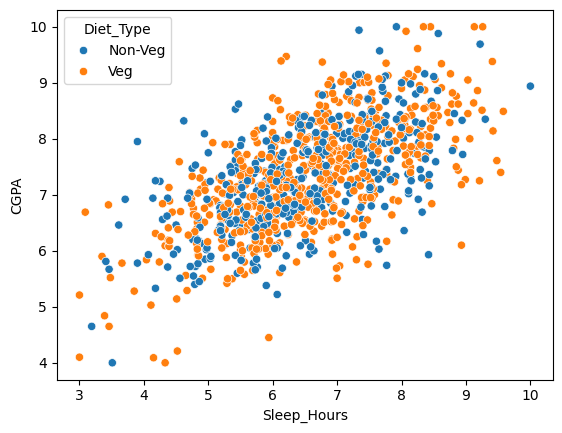

In [81]:
# wykres 1
df["Branch"] = df["Branch"].replace({
    "CSE": "IT"
})

sns.scatterplot(
    data=df,
    x="Sleep_Hours",
    y="CGPA",
    hue="Diet_Type"
)

plt.show()

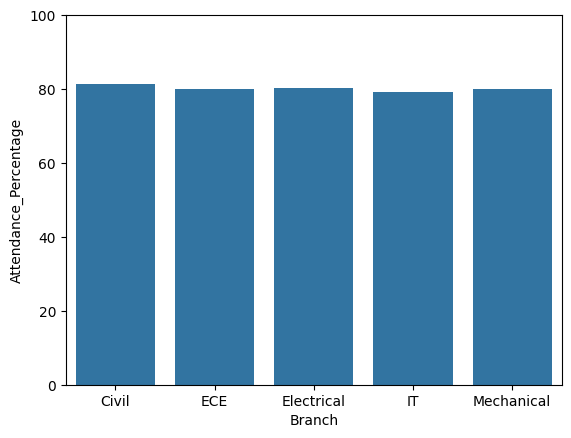

In [84]:
# wykres 2
attendance_mean = (
    df
    .groupby("Branch")["Attendance_Percentage"]
    .mean()
    .reset_index()
)

sns.barplot(
    data=attendance_mean,
    x="Branch",
    y="Attendance_Percentage"
)

plt.ylim(0, 100)
plt.show()

## Zadanie 5:
Utwórz wykresy, które pozwalają przedstawić następujące informacje:
- Najpopularniejsze tematy filmów na YouTube Shorts w ostatnim kwartale 2024 roku
- Jaki hasztag najbardziej opłaca się umieszczać w  postach na poszczególnych platformach?

In [85]:
# wczytanie danych do zadania 5
df = pd.read_csv("/content/social_media_viral_content_dataset.csv")

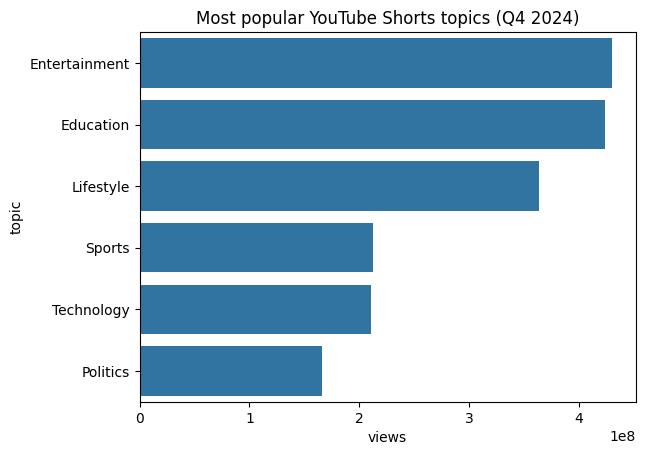

In [97]:
# wykres 1
df["post_datetime"] = pd.to_datetime(df["post_datetime"])

shorts_q4 = df[
    (df["platform"] == "YouTube Shorts") &
    (df["post_datetime"] >= "2024-10-01") &
    (df["post_datetime"] <= "2024-12-31")
]

topics = (
    shorts_q4
    .groupby("topic")["views"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

sns.barplot(
    data=topics,
    x="views",
    y="topic"
)

plt.title("Most popular YouTube Shorts topics (Q4 2024)")
plt.show()

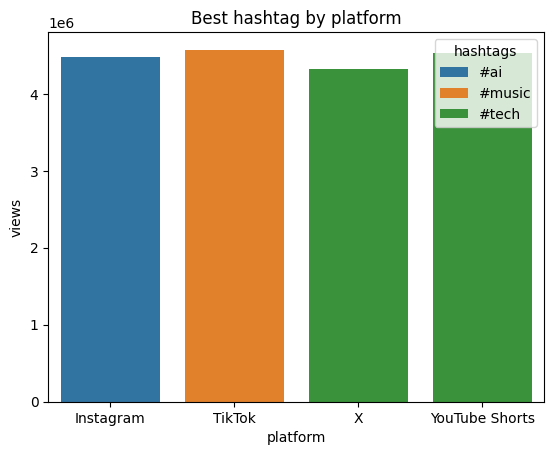

In [99]:
# wykres 2
df["hashtags"] = df["hashtags"].str.split(" ")
df = df.explode("hashtags")

hashtags = (
    df
    .groupby(["platform", "hashtags"])["views"]
    .mean()
    .reset_index()
)

best_hashtags = (
    hashtags
    .loc[hashtags.groupby("platform")["views"].idxmax()]
)

sns.barplot(
    data=best_hashtags,
    x="platform",
    y="views",
    hue="hashtags"
)

plt.title("Best hashtag by platform")
plt.show()